In [59]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [61]:
from ucimlrepo import fetch_ucirepo 
   
dry_bean = fetch_ucirepo(id=602) 
   
X = dry_bean.data.features 
y = dry_bean.data.targets 
  
print(dry_bean.metadata) 
  
print(dry_bean.variables) 

{'uci_id': 602, 'name': 'Dry Bean', 'repository_url': 'https://archive.ics.uci.edu/dataset/602/dry+bean+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/602/data.csv', 'abstract': 'Images of 13,611 grains of 7 different registered dry beans were taken with a high-resolution camera. A total of 16 features; 12 dimensions and 4 shape forms, were obtained from the grains.', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 13611, 'num_features': 16, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2020, 'last_updated': 'Thu Mar 28 2024', 'dataset_doi': '10.24432/C50S4B', 'creators': [], 'intro_paper': {'ID': 244, 'type': 'NATIVE', 'title': 'Multiclass classification of dry beans using computer vision and machine learning techniques', 'authors': 'M. Koklu, Ilker Ali Özkan', 'venue': 'Co

In [63]:
print(X)

        Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRatio  \
0      28395    610.291       208.178117       173.888747     1.197191   
1      28734    638.018       200.524796       182.734419     1.097356   
2      29380    624.110       212.826130       175.931143     1.209713   
3      30008    645.884       210.557999       182.516516     1.153638   
4      30140    620.134       201.847882       190.279279     1.060798   
...      ...        ...              ...              ...          ...   
13606  42097    759.696       288.721612       185.944705     1.552728   
13607  42101    757.499       281.576392       190.713136     1.476439   
13608  42139    759.321       281.539928       191.187979     1.472582   
13609  42147    763.779       283.382636       190.275731     1.489326   
13610  42159    772.237       295.142741       182.204716     1.619841   

       Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  Roundness  \
0          0.549812       2871

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay)

print(y["Class"].value_counts())

print(y["Class"].value_counts(normalize=True) * 100)

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64
Class
DERMASON    26.052458
SIRA        19.366689
SEKER       14.892366
HOROZ       14.165014
CALI        11.975608
BARBUNYA     9.712732
BOMBAY       3.835133
Name: proportion, dtype: float64


In [67]:
class_counts = y["Class"].value_counts()

incremental_order = class_counts.sort_values().index.tolist()

print("Incremental class order:")
for i, class_name in enumerate(incremental_order, start=1):
    print(i,class_name,class_counts[class_name])

Incremental class order:
1 BOMBAY 522
2 BARBUNYA 1322
3 CALI 1630
4 HOROZ 1928
5 SEKER 2027
6 SIRA 2636
7 DERMASON 3546


In [69]:
X = X.copy()
y_class = y["Class"].copy()

print("X shape:", X.shape)
print("y shape:", y_class.shape)
print("Number of classes:", y_class.nunique())

X shape: (13611, 16)
y shape: (13611,)
Number of classes: 7


In [71]:
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y_class)

print("Encoded classes:")
for i, class_name in enumerate(encoder.classes_):
    print(i, class_name)

Encoded classes:
0 BARBUNYA
1 BOMBAY
2 CALI
3 DERMASON
4 HOROZ
5 SEKER
6 SIRA


In [73]:
X_train, X_valtest, y_train, y_valtest = train_test_split(X,y_encoded,test_size=0.30,stratify=y_encoded,random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_valtest,y_valtest,test_size=0.50,stratify=y_valtest,random_state=42)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (9527, 16)
Validation: (2042, 16)
Test: (2042, 16)


In [75]:
scaler = StandardScaler()

X_train_preprocessed = scaler.fit_transform(X_train)
X_val_preprocessed = scaler.transform(X_val)
X_test_preprocessed = scaler.transform(X_test)

print(X_train_preprocessed.shape)

(9527, 16)


In [77]:
hidden_sizes = [1, 3, 5, 10, 15, 20]

baseline_tuning_results = []

for n_hidden in hidden_sizes:

    np.random.seed(42)
    tf.random.set_seed(42)

    model = keras.Sequential([
        keras.layers.Input(shape=(X_train_preprocessed.shape[1],)),
        keras.layers.Dense(n_hidden,activation="relu"),
        keras.layers.Dense(7,activation="softmax")])

    model.compile(optimizer="sgd",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

    history = model.fit(X_train_preprocessed,y_train,validation_data=(X_val_preprocessed,y_val),epochs=100,batch_size=32,verbose=0)

    best_epoch = (np.argmax(history.history["val_accuracy"]) + 1)

    best_val_accuracy = max(history.history["val_accuracy"])

    baseline_tuning_results.append({"Hidden neurons": n_hidden,"Best epoch": best_epoch,"Best validation accuracy": best_val_accuracy})

baseline_tuning = pd.DataFrame(baseline_tuning_results)

print(baseline_tuning)

   Hidden neurons  Best epoch  Best validation accuracy
0               1          71                  0.651322
1               3          97                  0.914300
2               5          92                  0.923115
3              10          96                  0.928501
4              15          67                  0.930950
5              20          95                  0.926543


In [81]:
best_hidden = baseline_tuning.loc[baseline_tuning["Best validation accuracy"].idxmax(),"Hidden neurons"]

best_hidden = int(best_hidden)

print("Selected hidden neurons:", best_hidden)

Selected hidden neurons: 15


In [83]:
np.random.seed(42)
tf.random.set_seed(42)

baseline_model = keras.Sequential([
    keras.layers.Input(shape=(X_train_preprocessed.shape[1],)),
    keras.layers.Dense(best_hidden,activation="relu"),
    keras.layers.Dense(7,activation="softmax")])

baseline_model.compile(optimizer="sgd",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

checkpoint_baseline = keras.callbacks.ModelCheckpoint("best_drybean_baseline.weights.h5",monitor="val_accuracy",mode="max",save_best_only=True,
                                                      save_weights_only=True, verbose=0)

baseline_history = baseline_model.fit(X_train_preprocessed,y_train,validation_data=(X_val_preprocessed,y_val),
    epochs=100,batch_size=32,callbacks=[checkpoint_baseline],verbose=1)

baseline_model.load_weights("best_drybean_baseline.weights.h5")

Epoch 1/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5779 - loss: 1.3153 - val_accuracy: 0.7027 - val_loss: 0.9252
Epoch 2/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7650 - loss: 0.7704 - val_accuracy: 0.8222 - val_loss: 0.6541
Epoch 3/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8525 - loss: 0.5787 - val_accuracy: 0.8702 - val_loss: 0.5208
Epoch 4/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8807 - loss: 0.4760 - val_accuracy: 0.8844 - val_loss: 0.4435
Epoch 5/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8943 - loss: 0.4133 - val_accuracy: 0.8947 - val_loss: 0.3929
Epoch 6/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9035 - loss: 0.3709 - val_accuracy: 0.9025 - val_loss: 0.3569
Epoch 7/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9088 - loss: 0.3401 - val_accuracy: 0.9074 - val_loss: 0.3298
Epoch 8/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9126 - loss: 0.3168 - val_accu

In [85]:
baseline_probabilities = baseline_model.predict(X_test_preprocessed,verbose=0)

baseline_predictions = np.argmax(baseline_probabilities,axis=1)

In [87]:
baseline_test_accuracy = accuracy_score(y_test,baseline_predictions)

print("Baseline test accuracy:",baseline_test_accuracy)

Baseline test accuracy: 0.9211557296767875


In [89]:
print(classification_report(y_test,baseline_predictions,target_names=encoder.classes_))

              precision    recall  f1-score   support

    BARBUNYA       0.93      0.90      0.92       199
      BOMBAY       1.00      0.99      0.99        78
        CALI       0.92      0.92      0.92       245
    DERMASON       0.93      0.90      0.91       532
       HOROZ       0.95      0.96      0.96       289
       SEKER       0.95      0.95      0.95       304
        SIRA       0.84      0.90      0.87       395

    accuracy                           0.92      2042
   macro avg       0.93      0.93      0.93      2042
weighted avg       0.92      0.92      0.92      2042



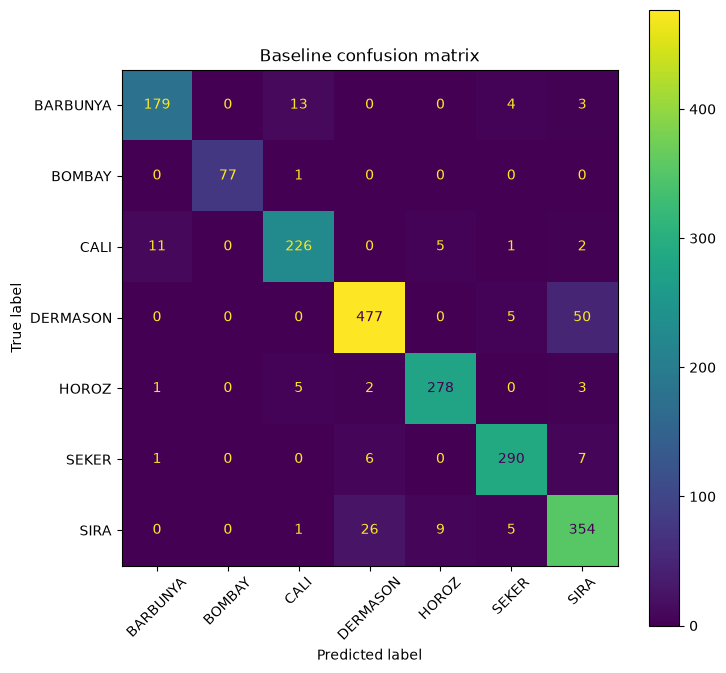

In [91]:
cm_baseline = confusion_matrix(y_test,baseline_predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_baseline,display_labels=encoder.classes_)

fig, ax = plt.subplots(figsize=(8, 8))

disp.plot(ax=ax,xticks_rotation=45)

ax.set_title("Baseline confusion matrix")

plt.show()

In [93]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(y_test,baseline_predictions,average="macro",zero_division=0)

weighted_precision, weighted_recall, weighted_f1, _ = (precision_recall_fscore_support(y_test,baseline_predictions,average="weighted",zero_division=0))

baseline_metrics = {"Accuracy": baseline_test_accuracy,"Macro precision": precision,"Macro recall": recall,"Macro F1": f1,"Weighted F1": weighted_f1}

print(pd.Series(baseline_metrics))

Accuracy           0.921156
Macro precision    0.933171
Macro recall       0.931119
Macro F1           0.931931
Weighted F1        0.921399
dtype: float64


In [95]:
class_counts = y_class.value_counts()

incremental_order = (class_counts.sort_values().index.tolist())

print("Incremental learning order:\n")

for i, class_name in enumerate(incremental_order,start=1):
    print(f"Stage {i}: {class_name} "
        f"({class_counts[class_name]} observations)")

Incremental learning order:

Stage 1: BOMBAY (522 observations)
Stage 2: BARBUNYA (1322 observations)
Stage 3: CALI (1630 observations)
Stage 4: HOROZ (1928 observations)
Stage 5: SEKER (2027 observations)
Stage 6: SIRA (2636 observations)
Stage 7: DERMASON (3546 observations)


In [103]:
def create_incremental_data(classes,X_train,y_train,X_val,y_val,X_test,y_test,encoder):

    class_ids = encoder.transform(classes)

    train_mask = np.isin(y_train, class_ids)
    val_mask = np.isin(y_val, class_ids)
    test_mask = np.isin(y_test, class_ids)

    X_train_stage = X_train[train_mask]
    X_val_stage = X_val[val_mask]
    X_test_stage = X_test[test_mask]

    y_train_original = y_train[train_mask]
    y_val_original = y_val[val_mask]
    y_test_original = y_test[test_mask]

    label_map = {class_id: i for i, class_id in enumerate(class_ids)}

    y_train_stage = np.array([label_map[value] for value in y_train_original])

    y_val_stage = np.array([label_map[value] for value in y_val_original])

    y_test_stage = np.array([label_map[value]for value in y_test_original])

    return (X_train_stage,y_train_stage,X_val_stage,y_val_stage,X_test_stage,y_test_stage)

In [105]:
(X_stage1_train,y_stage1_train,X_stage1_val,y_stage1_val,X_stage1_test,y_stage1_test) = create_incremental_data(
    stage1_classes,X_train_preprocessed,y_train,X_val_preprocessed,y_val,X_test_preprocessed,y_test,encoder)

print("Training:", X_stage1_train.shape)
print("Validation:", X_stage1_val.shape)
print("Test:", X_stage1_test.shape)

print("Training class counts:",np.bincount(y_stage1_train))

Training: (1290, 16)
Validation: (277, 16)
Test: (277, 16)
Training class counts: [365 925]


In [107]:
stage1_classes = incremental_order[:2]

print("Stage 1 classes:", stage1_classes)

(X_stage1_train,y_stage1_train,X_stage1_val,y_stage1_val,X_stage1_test,y_stage1_test) = create_incremental_data(
    stage1_classes,X_train_preprocessed,y_train,X_val_preprocessed,y_val,X_test_preprocessed,y_test,encoder)

print("Training:", X_stage1_train.shape)
print("Validation:", X_stage1_val.shape)
print("Test:", X_stage1_test.shape)

print("Training class counts:", np.bincount(y_stage1_train))
print("Validation class counts:", np.bincount(y_stage1_val))
print("Test class counts:", np.bincount(y_stage1_test))

Stage 1 classes: ['BOMBAY', 'BARBUNYA']
Training: (1290, 16)
Validation: (277, 16)
Test: (277, 16)
Training class counts: [365 925]
Validation class counts: [ 79 198]
Test class counts: [ 78 199]


In [113]:
np.random.seed(42)
tf.random.set_seed(42)

stage1_model_0hidden = keras.Sequential([
    keras.layers.Input(shape=(X_stage1_train.shape[1],)),
    keras.layers.Dense(2, activation="softmax")])

stage1_model_0hidden.compile(optimizer="sgd",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

checkpoint_stage1 = keras.callbacks.ModelCheckpoint("best_stage1.weights.h5",monitor="val_accuracy",mode="max",save_best_only=True,
    save_weights_only=True,verbose=0)

stage1_history_0hidden = stage1_model_0hidden.fit(X_stage1_train,y_stage1_train,validation_data=(X_stage1_val, y_stage1_val),
    epochs=100,batch_size=32,callbacks=[checkpoint_stage1],verbose=1)

stage1_model_0hidden.load_weights("best_stage1.weights.h5")

Epoch 1/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4721 - loss: 0.8576 - val_accuracy: 0.6715 - val_loss: 0.5804
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7868 - loss: 0.4775 - val_accuracy: 0.8628 - val_loss: 0.3879
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9031 - loss: 0.3423 - val_accuracy: 0.9278 - val_loss: 0.2943
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9357 - loss: 0.2691 - val_accuracy: 0.9567 - val_loss: 0.2394
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9566 - loss: 0.2231 - val_accuracy: 0.9567 - val_loss: 0.2031
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9682 - loss: 0.1912 - val_accuracy: 0.9675 - val_loss: 0.1771
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9767 - loss: 0.1677 - val_accuracy: 0.9783 - val_loss: 0.1575
Epoch 8/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9806 - loss: 0.1496 - val_accuracy: 0.9856 - v

In [115]:
best_epoch_stage1_0hidden = (np.argmax(stage1_history_0hidden.history["val_accuracy"]) + 1)

best_val_stage1_0hidden = max(stage1_history_0hidden.history["val_accuracy"])

print("Best epoch:", best_epoch_stage1_0hidden)
print("Best validation accuracy:", best_val_stage1_0hidden)

Best epoch: 29
Best validation accuracy: 1.0


In [117]:
stage2_classes = incremental_order[:3]

print(stage2_classes)

['BOMBAY', 'BARBUNYA', 'CALI']


In [119]:
(X_stage2_train,y_stage2_train,X_stage2_val,y_stage2_val,X_stage2_test,y_stage2_test) = create_incremental_data(
    stage2_classes,X_train_preprocessed,y_train,X_val_preprocessed,y_val,X_test_preprocessed,y_test,encoder)

print("Training:", X_stage2_train.shape)
print("Validation:", X_stage2_val.shape)
print("Test:", X_stage2_test.shape)

print("Training class counts:", np.bincount(y_stage2_train))
print("Validation class counts:", np.bincount(y_stage2_val))
print("Test class counts:", np.bincount(y_stage2_test))

Training: (2431, 16)
Validation: (521, 16)
Test: (522, 16)
Training class counts: [ 365  925 1141]
Validation class counts: [ 79 198 244]
Test class counts: [ 78 199 245]


In [121]:
stage1_weights, stage1_bias = (stage1_model_0hidden.layers[-1].get_weights())

In [123]:
np.random.seed(42)
tf.random.set_seed(42)

stage2_model = keras.Sequential([
    keras.layers.Input(shape=(X_stage2_train.shape[1],)),
    keras.layers.Dense(3, activation="softmax")])

stage2_model.compile(optimizer="sgd",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [125]:
stage2_weights, stage2_bias = (stage2_model.layers[-1].get_weights())

print("Stage 1 weights:", stage1_weights.shape)
print("Stage 1 bias:", stage1_bias.shape)

print("Stage 2 weights:", stage2_weights.shape)
print("Stage 2 bias:", stage2_bias.shape)

Stage 1 weights: (16, 2)
Stage 1 bias: (2,)
Stage 2 weights: (16, 3)
Stage 2 bias: (3,)


In [127]:
stage2_weights[:, :2] = stage1_weights
stage2_bias[:2] = stage1_bias

In [129]:
stage2_model.layers[-1].set_weights([stage2_weights,stage2_bias])

In [131]:
checkpoint_stage2 = keras.callbacks.ModelCheckpoint("best_stage2.weights.h5",monitor="val_accuracy",
    mode="max",save_best_only=True,save_weights_only=True,verbose=0)

stage2_history = stage2_model.fit(X_stage2_train,y_stage2_train,validation_data=(X_stage2_val, y_stage2_val),epochs=100,
    batch_size=32,callbacks=[checkpoint_stage2],verbose=1)

stage2_model.load_weights("best_stage2.weights.h5")

Epoch 1/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5812 - loss: 0.8390 - val_accuracy: 0.7793 - val_loss: 0.6101
Epoch 2/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8560 - loss: 0.5234 - val_accuracy: 0.9136 - val_loss: 0.4351
Epoch 3/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9268 - loss: 0.3988 - val_accuracy: 0.9367 - val_loss: 0.3547
Epoch 4/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9412 - loss: 0.3353 - val_accuracy: 0.9463 - val_loss: 0.3089
Epoch 5/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9461 - loss: 0.2964 - val_accuracy: 0.9482 - val_loss: 0.2790
Epoch 6/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9461 - loss: 0.2698 - val_accuracy: 0.9539 - val_loss: 0.2576
Epoch 7/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9486 - loss: 0.2501 - val_accuracy: 0.9578 - val_loss: 0.2414
Epoch 8/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9498 - loss: 0.2349 - val_accuracy: 0.9597 - v

In [133]:
best_epoch_stage2 = (np.argmax(stage2_history.history["val_accuracy"]) + 1)

best_val_stage2 = max(stage2_history.history["val_accuracy"])

print("Best epoch:", best_epoch_stage2)
print("Best validation accuracy:", best_val_stage2)

Best epoch: 19
Best validation accuracy: 0.9692898392677307


In [135]:
stage3_classes = incremental_order[:4]

print("Stage 3 classes:", stage3_classes)

(X_stage3_train,y_stage3_train,X_stage3_val,y_stage3_val,X_stage3_test,y_stage3_test) = create_incremental_data(
    stage3_classes,X_train_preprocessed,y_train,X_val_preprocessed,y_val,X_test_preprocessed,y_test,encoder)

print("Training:", X_stage3_train.shape)
print("Validation:", X_stage3_val.shape)
print("Test:", X_stage3_test.shape)

print("Training class counts:", np.bincount(y_stage3_train))
print("Validation class counts:", np.bincount(y_stage3_val))
print("Test class counts:", np.bincount(y_stage3_test))

Stage 3 classes: ['BOMBAY', 'BARBUNYA', 'CALI', 'HOROZ']
Training: (3781, 16)
Validation: (810, 16)
Test: (811, 16)
Training class counts: [ 365  925 1141 1350]
Validation class counts: [ 79 198 244 289]
Test class counts: [ 78 199 245 289]


In [137]:
np.random.seed(42)
tf.random.set_seed(42)

stage3_model = keras.Sequential([
    keras.layers.Input(shape=(X_stage3_train.shape[1],)),
    keras.layers.Dense(4, activation="softmax")])

stage3_model.compile(optimizer="sgd",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [139]:
stage2_weights, stage2_bias = (stage2_model.layers[-1].get_weights())

stage3_weights, stage3_bias = (stage3_model.layers[-1].get_weights())

print("Stage 2 weights:", stage2_weights.shape)
print("Stage 2 bias:", stage2_bias.shape)

print("Stage 3 weights:", stage3_weights.shape)
print("Stage 3 bias:", stage3_bias.shape)

Stage 2 weights: (16, 3)
Stage 2 bias: (3,)
Stage 3 weights: (16, 4)
Stage 3 bias: (4,)


In [141]:
stage3_weights[:, :3] = stage2_weights
stage3_bias[:3] = stage2_bias

stage3_model.layers[-1].set_weights([stage3_weights,stage3_bias])

In [143]:
checkpoint_stage3 = keras.callbacks.ModelCheckpoint("best_stage3.weights.h5",monitor="val_accuracy",mode="max",
    save_best_only=True,save_weights_only=True,verbose=0)

stage3_history = stage3_model.fit(X_stage3_train,y_stage3_train,validation_data=(X_stage3_val, y_stage3_val),epochs=100,
    batch_size=32,callbacks=[checkpoint_stage3],verbose=1)

stage3_model.load_weights("best_stage3.weights.h5")

Epoch 1/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7657 - loss: 0.7136 - val_accuracy: 0.9111 - val_loss: 0.3331
Epoch 2/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9214 - loss: 0.3094 - val_accuracy: 0.9457 - val_loss: 0.2672
Epoch 3/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9405 - loss: 0.2672 - val_accuracy: 0.9531 - val_loss: 0.2412
Epoch 4/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9434 - loss: 0.2455 - val_accuracy: 0.9556 - val_loss: 0.2248
Epoch 5/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9455 - loss: 0.2307 - val_accuracy: 0.9568 - val_loss: 0.2128
Epoch 6/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9468 - loss: 0.2195 - val_accuracy: 0.9605 - val_loss: 0.2034
Epoch 7/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9482 - loss: 0.2107 - val_accuracy: 0.9642 - val_loss: 0.1958
Epoch 8/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9487 - loss: 0.2033 - val_accu

In [145]:
best_epoch_stage3 = (np.argmax(stage3_history.history["val_accuracy"]) + 1)

best_val_stage3 = max(stage3_history.history["val_accuracy"])

print("Best epoch:", best_epoch_stage3)
print("Best validation accuracy:", best_val_stage3)

Best epoch: 87
Best validation accuracy: 0.9728395342826843


In [147]:
stage4_classes = incremental_order[:5]

print("Stage 4 classes:", stage4_classes)

Stage 4 classes: ['BOMBAY', 'BARBUNYA', 'CALI', 'HOROZ', 'SEKER']


In [149]:
(X_stage4_train,y_stage4_train,X_stage4_val,y_stage4_val,X_stage4_test,y_stage4_test) = create_incremental_data(
    stage4_classes,X_train_preprocessed,y_train,X_val_preprocessed,y_val,X_test_preprocessed,y_test,encoder)

print("Training:", X_stage4_train.shape)
print("Validation:", X_stage4_val.shape)
print("Test:", X_stage4_test.shape)

print("Training class counts:", np.bincount(y_stage4_train))
print("Validation class counts:", np.bincount(y_stage4_val))
print("Test class counts:", np.bincount(y_stage4_test))

Training: (5200, 16)
Validation: (1114, 16)
Test: (1115, 16)
Training class counts: [ 365  925 1141 1350 1419]
Validation class counts: [ 79 198 244 289 304]
Test class counts: [ 78 199 245 289 304]


In [151]:
np.random.seed(42)
tf.random.set_seed(42)

stage4_model = keras.Sequential([
    keras.layers.Input(shape=(X_stage4_train.shape[1],)),
    keras.layers.Dense(5, activation="softmax")])

stage4_model.compile(optimizer="sgd",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [153]:
stage3_weights, stage3_bias = (stage3_model.layers[-1].get_weights())

stage4_weights, stage4_bias = (stage4_model.layers[-1].get_weights())

print("Stage 3 weights:", stage3_weights.shape)
print("Stage 3 bias:", stage3_bias.shape)

print("Stage 4 weights:", stage4_weights.shape)
print("Stage 4 bias:", stage4_bias.shape)

Stage 3 weights: (16, 4)
Stage 3 bias: (4,)
Stage 4 weights: (16, 5)
Stage 4 bias: (5,)


In [155]:
stage4_weights[:, :4] = stage3_weights
stage4_bias[:4] = stage3_bias

stage4_model.layers[-1].set_weights([stage4_weights,stage4_bias])

In [157]:
checkpoint_stage4 = keras.callbacks.ModelCheckpoint("best_stage4.weights.h5",monitor="val_accuracy",mode="max",
    save_best_only=True,save_weights_only=True,verbose=0)

stage4_history = stage4_model.fit(X_stage4_train,y_stage4_train,validation_data=(X_stage4_val, y_stage4_val),epochs=100,batch_size=32,
    callbacks=[checkpoint_stage4],verbose=1)

stage4_model.load_weights("best_stage4.weights.h5")

Epoch 1/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8454 - loss: 0.4972 - val_accuracy: 0.9434 - val_loss: 0.2135
Epoch 2/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9506 - loss: 0.1868 - val_accuracy: 0.9533 - val_loss: 0.1663
Epoch 3/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9562 - loss: 0.1629 - val_accuracy: 0.9569 - val_loss: 0.1506
Epoch 4/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9587 - loss: 0.1527 - val_accuracy: 0.9578 - val_loss: 0.1422
Epoch 5/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9598 - loss: 0.1466 - val_accuracy: 0.9614 - val_loss: 0.1367
Epoch 6/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9608 - loss: 0.1425 - val_accuracy: 0.9650 - val_loss: 0.1329
Epoch 7/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9623 - loss: 0.1394 - val_accuracy: 0.9650 - val_loss: 0.1299
Epoch 8/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9623 - loss: 0.1370 - val_accu

In [159]:
best_epoch_stage4 = (np.argmax(stage4_history.history["val_accuracy"]) + 1)

best_val_stage4 = max(stage4_history.history["val_accuracy"])

print("Best epoch:", best_epoch_stage4)
print("Best validation accuracy:", best_val_stage4)

Best epoch: 87
Best validation accuracy: 0.9730700254440308


In [161]:
stage5_classes = incremental_order[:6]

print("Stage 5 classes:", stage5_classes)

Stage 5 classes: ['BOMBAY', 'BARBUNYA', 'CALI', 'HOROZ', 'SEKER', 'SIRA']


In [163]:
(X_stage5_train,y_stage5_train,X_stage5_val,y_stage5_val,X_stage5_test,y_stage5_test) = create_incremental_data(
    stage5_classes,X_train_preprocessed,y_train,X_val_preprocessed,y_val,X_test_preprocessed,y_test,encoder)

print("Training:", X_stage5_train.shape)
print("Validation:", X_stage5_val.shape)
print("Test:", X_stage5_test.shape)

print("Training class counts:", np.bincount(y_stage5_train))
print("Validation class counts:", np.bincount(y_stage5_val))
print("Test class counts:", np.bincount(y_stage5_test))

Training: (7045, 16)
Validation: (1510, 16)
Test: (1510, 16)
Training class counts: [ 365  925 1141 1350 1419 1845]
Validation class counts: [ 79 198 244 289 304 396]
Test class counts: [ 78 199 245 289 304 395]


In [165]:
np.random.seed(42)
tf.random.set_seed(42)

stage5_model = keras.Sequential([
    keras.layers.Input(shape=(X_stage5_train.shape[1],)),
    keras.layers.Dense(6, activation="softmax")])

stage5_model.compile(optimizer="sgd",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [167]:
stage4_weights, stage4_bias = (stage4_model.layers[-1].get_weights())
stage5_weights, stage5_bias = (stage5_model.layers[-1].get_weights())

stage5_weights[:, :5] = stage4_weights
stage5_bias[:5] = stage4_bias

stage5_model.layers[-1].set_weights([stage5_weights,stage5_bias])

In [169]:
checkpoint_stage5 = keras.callbacks.ModelCheckpoint("best_stage5.weights.h5",monitor="val_accuracy",mode="max",save_best_only=True,
    save_weights_only=True,verbose=0)

stage5_history = stage5_model.fit(X_stage5_train,y_stage5_train,validation_data=(X_stage5_val, y_stage5_val),epochs=100,
    batch_size=32,callbacks=[checkpoint_stage5],verbose=1)

stage5_model.load_weights("best_stage5.weights.h5")

Epoch 1/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7124 - loss: 0.8200 - val_accuracy: 0.7192 - val_loss: 0.6819
Epoch 2/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7492 - loss: 0.5839 - val_accuracy: 0.8033 - val_loss: 0.4840
Epoch 3/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8329 - loss: 0.4287 - val_accuracy: 0.8662 - val_loss: 0.3648
Epoch 4/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8852 - loss: 0.3377 - val_accuracy: 0.8993 - val_loss: 0.2967
Epoch 5/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9113 - loss: 0.2848 - val_accuracy: 0.9205 - val_loss: 0.2570
Epoch 6/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9249 - loss: 0.2531 - val_accuracy: 0.9344 - val_loss: 0.2332
Epoch 7/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9339 - loss: 0.2337 - val_accuracy: 0.9391 - val_loss: 0.2185
Epoch 8/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9412 - loss: 0.2213 - val_accu

In [171]:
best_epoch_stage5 = (np.argmax(stage5_history.history["val_accuracy"]) + 1)

best_val_stage5 = max(stage5_history.history["val_accuracy"])

print("Best epoch:", best_epoch_stage5)
print("Best validation accuracy:", best_val_stage5)

Best epoch: 89
Best validation accuracy: 0.9556291103363037


In [173]:
stage6_classes = incremental_order[:7]

print("Stage 6 classes:", stage6_classes)

Stage 6 classes: ['BOMBAY', 'BARBUNYA', 'CALI', 'HOROZ', 'SEKER', 'SIRA', 'DERMASON']


In [175]:
(X_stage6_train,y_stage6_train,X_stage6_val,y_stage6_val,X_stage6_test,y_stage6_test) = create_incremental_data(
    stage6_classes,X_train_preprocessed,y_train,X_val_preprocessed,y_val,X_test_preprocessed,y_test,encoder)

print("Training:", X_stage6_train.shape)
print("Validation:", X_stage6_val.shape)
print("Test:", X_stage6_test.shape)

print("Training class counts:", np.bincount(y_stage6_train))
print("Validation class counts:", np.bincount(y_stage6_val))
print("Test class counts:", np.bincount(y_stage6_test))

Training: (9527, 16)
Validation: (2042, 16)
Test: (2042, 16)
Training class counts: [ 365  925 1141 1350 1419 1845 2482]
Validation class counts: [ 79 198 244 289 304 396 532]
Test class counts: [ 78 199 245 289 304 395 532]


In [177]:
np.random.seed(42)
tf.random.set_seed(42)

stage6_model = keras.Sequential([
    keras.layers.Input(shape=(X_stage6_train.shape[1],)),
    keras.layers.Dense(7, activation="softmax")])

stage6_model.compile(optimizer="sgd",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

stage5_weights, stage5_bias = (stage5_model.layers[-1].get_weights())

stage6_weights, stage6_bias = (stage6_model.layers[-1].get_weights())

stage6_weights[:, :6] = stage5_weights
stage6_bias[:6] = stage5_bias

stage6_model.layers[-1].set_weights([stage6_weights,stage6_bias])

In [179]:
checkpoint_stage6 = keras.callbacks.ModelCheckpoint("best_stage6.weights.h5",monitor="val_accuracy",mode="max",
    save_best_only=True,save_weights_only=True,verbose=0)

stage6_history = stage6_model.fit(X_stage6_train,y_stage6_train,validation_data=(X_stage6_val, y_stage6_val),epochs=100,
    batch_size=32,callbacks=[checkpoint_stage6],verbose=1)

stage6_model.load_weights("best_stage6.weights.h5")

Epoch 1/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7063 - loss: 1.4096 - val_accuracy: 0.7904 - val_loss: 0.5002
Epoch 2/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8726 - loss: 0.3844 - val_accuracy: 0.9021 - val_loss: 0.3169
Epoch 3/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9054 - loss: 0.3179 - val_accuracy: 0.9094 - val_loss: 0.2905
Epoch 4/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9114 - loss: 0.2975 - val_accuracy: 0.9163 - val_loss: 0.2766
Epoch 5/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9152 - loss: 0.2851 - val_accuracy: 0.9192 - val_loss: 0.2679
Epoch 6/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9179 - loss: 0.2765 - val_accuracy: 0.9197 - val_loss: 0.2620
Epoch 7/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9187 - loss: 0.2704 - val_accuracy: 0.9192 - val_loss: 0.2578
Epoch 8/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9194 - loss: 0.2657 - val_accu

In [181]:
best_epoch_stage6 = (np.argmax(stage6_history.history["val_accuracy"]) + 1)

best_val_stage6 = max(stage6_history.history["val_accuracy"])

print("Best epoch:", best_epoch_stage6)
print("Best validation accuracy:", best_val_stage6)

Best epoch: 88
Best validation accuracy: 0.924094021320343


In [183]:
best_epoch_stage6 = (np.argmax(stage6_history.history["val_accuracy"]) + 1)

print("Training accuracy at best epoch:",stage6_history.history["accuracy"][best_epoch_stage6 - 1])

print("Validation accuracy at best epoch:",stage6_history.history["val_accuracy"][best_epoch_stage6 - 1])

Training accuracy at best epoch: 0.924950122833252
Validation accuracy at best epoch: 0.924094021320343


In [185]:
np.random.seed(42)
tf.random.set_seed(42)

stage6_model_1hidden = keras.Sequential([
    keras.layers.Input(shape=(X_stage6_train.shape[1],)),
    keras.layers.Dense(1, activation="relu"),
    keras.layers.Dense(7, activation="softmax")])

stage6_model_1hidden.compile(optimizer="sgd",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [187]:
checkpoint_stage6_1hidden = keras.callbacks.ModelCheckpoint("best_stage6_1hidden.weights.h5",monitor="val_accuracy",
    mode="max",save_best_only=True,save_weights_only=True,verbose=0)

stage6_history_1hidden = stage6_model_1hidden.fit(X_stage6_train,y_stage6_train,validation_data=(X_stage6_val, y_stage6_val),
    epochs=100,batch_size=32,callbacks=[checkpoint_stage6_1hidden],verbose=1)

stage6_model_1hidden.load_weights("best_stage6_1hidden.weights.h5")

Epoch 1/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3789 - loss: 1.8281 - val_accuracy: 0.3781 - val_loss: 1.7357
Epoch 2/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3829 - loss: 1.6766 - val_accuracy: 0.3834 - val_loss: 1.6269
Epoch 3/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3899 - loss: 1.5884 - val_accuracy: 0.3898 - val_loss: 1.5543
Epoch 4/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3938 - loss: 1.5251 - val_accuracy: 0.3976 - val_loss: 1.4999
Epoch 5/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4062 - loss: 1.4785 - val_accuracy: 0.4153 - val_loss: 1.4591
Epoch 6/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4204 - loss: 1.4430 - val_accuracy: 0.4261 - val_loss: 1.4266
Epoch 7/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4325 - loss: 1.4143 - val_accuracy: 0.4334 - val_loss: 1.3994
Epoch 8/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4414 - loss: 1.3901 - val_accu

In [189]:
best_epoch_stage6_1hidden = (np.argmax(stage6_history_1hidden.history["val_accuracy"]) + 1)

best_val_stage6_1hidden = max(stage6_history_1hidden.history["val_accuracy"])

best_train_stage6_1hidden = (stage6_history_1hidden.history["accuracy"][best_epoch_stage6_1hidden - 1])

print("Best epoch:",best_epoch_stage6_1hidden)

print("Training accuracy at best epoch:",best_train_stage6_1hidden)

print("Validation accuracy at best epoch:",best_val_stage6_1hidden)

Best epoch: 100
Training accuracy at best epoch: 0.5741576552391052
Validation accuracy at best epoch: 0.5808031558990479


In [191]:
np.random.seed(42)
tf.random.set_seed(42)

stage6_model_2hidden = keras.Sequential([
    keras.layers.Input(shape=(X_stage6_train.shape[1],)),
    keras.layers.Dense(2, activation="relu"),
    keras.layers.Dense(7, activation="softmax")])

stage6_model_2hidden.compile(optimizer="sgd",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [193]:
checkpoint_stage6_2hidden = keras.callbacks.ModelCheckpoint("best_stage6_2hidden.weights.h5",monitor="val_accuracy",
    mode="max",save_best_only=True,save_weights_only=True,verbose=0)

stage6_history_2hidden = stage6_model_2hidden.fit(X_stage6_train,y_stage6_train,validation_data=(X_stage6_val, y_stage6_val),
    epochs=100,batch_size=32,callbacks=[checkpoint_stage6_2hidden],verbose=1)

stage6_model_2hidden.load_weights("best_stage6_2hidden.weights.h5")

Epoch 1/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3578 - loss: 1.5444 - val_accuracy: 0.4868 - val_loss: 1.3440
Epoch 2/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5128 - loss: 1.2760 - val_accuracy: 0.5446 - val_loss: 1.2091
Epoch 3/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5723 - loss: 1.1759 - val_accuracy: 0.5940 - val_loss: 1.1317
Epoch 4/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6068 - loss: 1.1102 - val_accuracy: 0.6224 - val_loss: 1.0755
Epoch 5/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6308 - loss: 1.0604 - val_accuracy: 0.6381 - val_loss: 1.0314
Epoch 6/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6431 - loss: 1.0205 - val_accuracy: 0.6518 - val_loss: 0.9956
Epoch 7/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6521 - loss: 0.9878 - val_accuracy: 0.6582 - val_loss: 0.9658
Epoch 8/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6558 - loss: 0.9605 - val_accu

In [195]:
best_epoch_stage6_2hidden = (np.argmax(stage6_history_2hidden.history["val_accuracy"]) + 1)

best_val_stage6_2hidden = max(stage6_history_2hidden.history["val_accuracy"])

best_train_stage6_2hidden = (stage6_history_2hidden.history["accuracy"][best_epoch_stage6_2hidden - 1])

print("Best epoch:", best_epoch_stage6_2hidden)
print("Training accuracy at best epoch:",best_train_stage6_2hidden)
print("Validation accuracy at best epoch:",best_val_stage6_2hidden)

Best epoch: 94
Training accuracy at best epoch: 0.892516016960144
Validation accuracy at best epoch: 0.8937316536903381


In [197]:
np.random.seed(42)
tf.random.set_seed(42)

stage6_model_3hidden = keras.Sequential([
    keras.layers.Input(shape=(X_stage6_train.shape[1],)),
    keras.layers.Dense(3, activation="relu"),
    keras.layers.Dense(7, activation="softmax")])

stage6_model_3hidden.compile(optimizer="sgd",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

checkpoint_stage6_3hidden = keras.callbacks.ModelCheckpoint("best_stage6_3hidden.weights.h5",monitor="val_accuracy",mode="max",
    save_best_only=True,save_weights_only=True,verbose=0)

stage6_history_3hidden = stage6_model_3hidden.fit(X_stage6_train,y_stage6_train,validation_data=(X_stage6_val, y_stage6_val),
    epochs=100,batch_size=32,callbacks=[checkpoint_stage6_3hidden],verbose=1)

stage6_model_3hidden.load_weights("best_stage6_3hidden.weights.h5")

best_epoch_stage6_3hidden = (np.argmax(stage6_history_3hidden.history["val_accuracy"]) + 1)

best_val_stage6_3hidden = max(stage6_history_3hidden.history["val_accuracy"])

best_train_stage6_3hidden = (stage6_history_3hidden.history["accuracy"][best_epoch_stage6_3hidden - 1])

print("Best epoch:", best_epoch_stage6_3hidden)
print("Training accuracy at best epoch:",best_train_stage6_3hidden)
print("Validation accuracy at best epoch:",best_val_stage6_3hidden)

Epoch 1/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2393 - loss: 1.7416 - val_accuracy: 0.3947 - val_loss: 1.4589
Epoch 2/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4733 - loss: 1.3097 - val_accuracy: 0.5044 - val_loss: 1.1815
Epoch 3/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5644 - loss: 1.0691 - val_accuracy: 0.5930 - val_loss: 0.9762
Epoch 4/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6456 - loss: 0.9166 - val_accuracy: 0.6601 - val_loss: 0.8698
Epoch 5/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6752 - loss: 0.8324 - val_accuracy: 0.6802 - val_loss: 0.8003
Epoch 6/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7258 - loss: 0.7730 - val_accuracy: 0.7512 - val_loss: 0.7480
Epoch 7/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7732 - loss: 0.7266 - val_accuracy: 0.7791 - val_loss: 0.7061
Epoch 8/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7952 - loss: 0.6883 - val_accu

In [199]:
np.random.seed(42)
tf.random.set_seed(42)

stage6_model_4hidden = keras.Sequential([
    keras.layers.Input(shape=(X_stage6_train.shape[1],)),
    keras.layers.Dense(4, activation="relu"),
    keras.layers.Dense(7, activation="softmax")])

stage6_model_4hidden.compile(optimizer="sgd",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

checkpoint_stage6_4hidden = keras.callbacks.ModelCheckpoint("best_stage6_4hidden.weights.h5",monitor="val_accuracy",mode="max",
    save_best_only=True,save_weights_only=True,verbose=0)

stage6_history_4hidden = stage6_model_4hidden.fit(X_stage6_train,y_stage6_train,validation_data=(X_stage6_val, y_stage6_val),
    epochs=100,batch_size=32,callbacks=[checkpoint_stage6_4hidden],verbose=1)

stage6_model_4hidden.load_weights("best_stage6_4hidden.weights.h5")

best_epoch_stage6_4hidden = (np.argmax(stage6_history_4hidden.history["val_accuracy"]) + 1)

best_val_stage6_4hidden = max(stage6_history_4hidden.history["val_accuracy"])

best_train_stage6_4hidden = (stage6_history_4hidden.history["accuracy"][best_epoch_stage6_4hidden - 1])

print("Best epoch:", best_epoch_stage6_4hidden)
print("Training accuracy at best epoch:",best_train_stage6_4hidden)
print("Validation accuracy at best epoch:",best_val_stage6_4hidden)

Epoch 1/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4111 - loss: 1.5547 - val_accuracy: 0.5411 - val_loss: 1.2174
Epoch 2/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5703 - loss: 1.0607 - val_accuracy: 0.5975 - val_loss: 0.9475
Epoch 3/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6636 - loss: 0.8506 - val_accuracy: 0.7209 - val_loss: 0.7702
Epoch 4/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7636 - loss: 0.6993 - val_accuracy: 0.8149 - val_loss: 0.6440
Epoch 5/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8322 - loss: 0.5981 - val_accuracy: 0.8266 - val_loss: 0.5657
Epoch 6/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8443 - loss: 0.5345 - val_accuracy: 0.8340 - val_loss: 0.5150
Epoch 7/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8538 - loss: 0.4922 - val_accuracy: 0.8433 - val_loss: 0.4800
Epoch 8/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8599 - loss: 0.4623 - val_accu

In [201]:
np.random.seed(42)
tf.random.set_seed(42)

stage6_model_5hidden = keras.Sequential([
    keras.layers.Input(shape=(X_stage6_train.shape[1],)),
    keras.layers.Dense(5, activation="relu"),
    keras.layers.Dense(7, activation="softmax")])

stage6_model_5hidden.compile(optimizer="sgd",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

checkpoint_stage6_5hidden = keras.callbacks.ModelCheckpoint("best_stage6_5hidden.weights.h5",monitor="val_accuracy",mode="max",
    save_best_only=True,save_weights_only=True,verbose=0)

stage6_history_5hidden = stage6_model_5hidden.fit(X_stage6_train,y_stage6_train,validation_data=(X_stage6_val, y_stage6_val),
    epochs=100,batch_size=32,callbacks=[checkpoint_stage6_5hidden],verbose=1)

stage6_model_5hidden.load_weights("best_stage6_5hidden.weights.h5")

best_epoch_stage6_5hidden = (np.argmax(stage6_history_5hidden.history["val_accuracy"]) + 1)

best_val_stage6_5hidden = max(stage6_history_5hidden.history["val_accuracy"])

best_train_stage6_5hidden = (stage6_history_5hidden.history["accuracy"][best_epoch_stage6_5hidden - 1])

print("Best epoch:", best_epoch_stage6_5hidden)
print("Training accuracy at best epoch:",best_train_stage6_5hidden)
print("Validation accuracy at best epoch:",best_val_stage6_5hidden)

Epoch 1/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4358 - loss: 1.5162 - val_accuracy: 0.5113 - val_loss: 1.2941
Epoch 2/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5675 - loss: 1.1893 - val_accuracy: 0.5916 - val_loss: 1.1132
Epoch 3/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6356 - loss: 1.0451 - val_accuracy: 0.6557 - val_loss: 0.9925
Epoch 4/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6727 - loss: 0.9418 - val_accuracy: 0.6978 - val_loss: 0.9007
Epoch 5/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7082 - loss: 0.8623 - val_accuracy: 0.7302 - val_loss: 0.8284
Epoch 6/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7549 - loss: 0.7984 - val_accuracy: 0.7733 - val_loss: 0.7696
Epoch 7/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7707 - loss: 0.7460 - val_accuracy: 0.7850 - val_loss: 0.7213
Epoch 8/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7764 - loss: 0.7030 - val_accu

In [203]:
stage6_test_pred_probs = stage6_model_5hidden.predict(X_stage6_test,verbose=0)

stage6_test_pred = np.argmax(stage6_test_pred_probs,axis=1)

stage6_test_accuracy = accuracy_score(y_stage6_test,stage6_test_pred)
print("Incremental test accuracy:", stage6_test_accuracy)

Incremental test accuracy: 0.9177277179236043


In [205]:
stage6_classes = ["BOMBAY","BARBUNYA","CALI","HOROZ","SEKER","SIRA","DERMASON"]

print(classification_report(y_stage6_test,stage6_test_pred,target_names=stage6_classes))

              precision    recall  f1-score   support

      BOMBAY       1.00      0.99      0.99        78
    BARBUNYA       0.93      0.88      0.91       199
        CALI       0.92      0.93      0.92       245
       HOROZ       0.95      0.96      0.96       289
       SEKER       0.94      0.94      0.94       304
        SIRA       0.84      0.89      0.86       395
    DERMASON       0.93      0.90      0.91       532

    accuracy                           0.92      2042
   macro avg       0.93      0.93      0.93      2042
weighted avg       0.92      0.92      0.92      2042



In [207]:
stage6_report = classification_report(y_stage6_test,stage6_test_pred,target_names=stage6_classes,output_dict=True)

print("Accuracy:", accuracy_score(y_stage6_test,stage6_test_pred))

print("Macro precision:", stage6_report["macro avg"]["precision"])
print("Macro recall:", stage6_report["macro avg"]["recall"])
print("Macro F1:", stage6_report["macro avg"]["f1-score"])
print("Weighted F1:", stage6_report["weighted avg"]["f1-score"])

Accuracy: 0.9177277179236043
Macro precision: 0.9301588040257951
Macro recall: 0.9273218155923942
Macro F1: 0.9285075342022192
Weighted F1: 0.9179513389826567
